In [ ]:
# Monta o Google Drive no Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

pasta = '/content/drive/MyDrive/Bases de Dados'

# Base do ENEM (formato SAS)
enem = pd.read_sas(f'{pasta}/enem_2024_amostra_perfeita.sas7bdat', encoding='latin-1')

# Base do SUS (CSV)
sus = pd.read_csv(f'{pasta}/sus_prod_ambulatorial.csv', sep=';', encoding='latin-1')

print("ENEM:", enem.shape, "linhas x colunas")
print("SUS:", sus.shape, "linhas x colunas")

ENEM: (67487, 32) linhas x colunas
SUS: (94707, 33) linhas x colunas


In [ ]:
print("Colunas do ENEM:")
print(list(enem.columns))

Colunas do ENEM:
['NU_ANO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'Municipio_Capital_UF_Prova', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Nome_UF_Prova', 'Regiao_Codigo_Prova', 'Regiao_Nome_Prova', 'TP_FAIXA_ETARIA', 'Idade_Calculada', 'TP_Sexo', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'TP_LINGUA', 'TP_STATUS_REDACAO', 'NOTA_CN_CIENCIAS_DA_NATUREZA', 'NOTA_CH_CIENCIAS_HUMANAS', 'NOTA_LC_LINGUAGENS_E_CODIGOS', 'NOTA_MT_MATEMATICA', 'NOTA_REDACAO', 'NOTA_MEDIA_5_NOTAS', 'LATITUDE', 'LONGITUDE']


In [ ]:
print("Colunas do ENEM:")
for c in enem.columns:
    print(" -", c)

Colunas do ENEM:
 - NU_ANO
 - CO_MUNICIPIO_PROVA
 - NO_MUNICIPIO_PROVA
 - Municipio_Capital_UF_Prova
 - CO_UF_PROVA
 - SG_UF_PROVA
 - Nome_UF_Prova
 - Regiao_Codigo_Prova
 - Regiao_Nome_Prova
 - TP_FAIXA_ETARIA
 - Idade_Calculada
 - TP_Sexo
 - TP_ESTADO_CIVIL
 - TP_COR_RACA
 - TP_NACIONALIDADE
 - TP_ST_CONCLUSAO
 - TP_ANO_CONCLUIU
 - TP_ENSINO
 - IN_TREINEIRO
 - TP_DEPENDENCIA_ADM_ESC
 - TP_LOCALIZACAO_ESC
 - TP_SIT_FUNC_ESC
 - TP_LINGUA
 - TP_STATUS_REDACAO
 - NOTA_CN_CIENCIAS_DA_NATUREZA
 - NOTA_CH_CIENCIAS_HUMANAS
 - NOTA_LC_LINGUAGENS_E_CODIGOS
 - NOTA_MT_MATEMATICA
 - NOTA_REDACAO
 - NOTA_MEDIA_5_NOTAS
 - LATITUDE
 - LONGITUDE


In [ ]:
print("Colunas relacionadas ao exercício:\n")
for c in enem.columns:
    if any(p in c.upper() for p in ['COR', 'RACA', 'RAÇA', 'MAT', 'NOTA', 'UF', 'SG_']):
        print(" -", c)

Colunas relacionadas ao exercício:

 - Municipio_Capital_UF_Prova
 - CO_UF_PROVA
 - SG_UF_PROVA
 - Nome_UF_Prova
 - TP_COR_RACA
 - NOTA_CN_CIENCIAS_DA_NATUREZA
 - NOTA_CH_CIENCIAS_HUMANAS
 - NOTA_LC_LINGUAGENS_E_CODIGOS
 - NOTA_MT_MATEMATICA
 - NOTA_REDACAO
 - NOTA_MEDIA_5_NOTAS


In [ ]:
# Diagnóstico: o que realmente tem na coluna TP_COR_RACA
print("Tipo da coluna:", enem['TP_COR_RACA'].dtype)
print("\nValores únicos:")
print(enem['TP_COR_RACA'].unique())
print("\nContagem bruta (sem mapear):")
print(enem['TP_COR_RACA'].value_counts(dropna=False))

Tipo da coluna: object

Valores únicos:
['Branca' 'Parda' 'Amarela' 'Preta' 'Indígena' 'Não declarado']

Contagem bruta (sem mapear):
TP_COR_RACA
Branca           29443
Parda            27675
Preta             8248
Amarela            988
Não declarado      716
Indígena           417
Name: count, dtype: int64


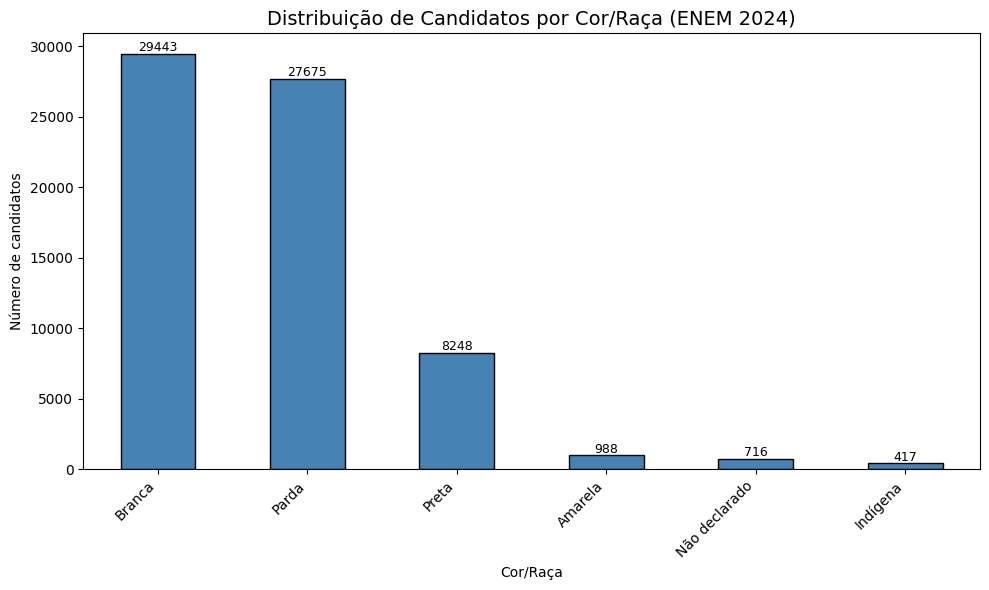

In [ ]:
import matplotlib.pyplot as plt

# A coluna já vem com os nomes por extenso, então é só contar
contagem = enem['TP_COR_RACA'].value_counts()

# Gráfico de barras
plt.figure(figsize=(10, 6))
contagem.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribuição de Candidatos por Cor/Raça (ENEM 2024)', fontsize=14)
plt.xlabel('Cor/Raça')
plt.ylabel('Número de candidatos')
plt.xticks(rotation=45, ha='right')

# Mostra o valor no topo de cada barra (opcional, fica mais profissional)
for i, v in enumerate(contagem):
    plt.text(i, v + 200, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# --- Parte 1: filtrar alunos com nota de matemática > 680 ---
acima_680 = enem[enem['NOTA_MT_MATEMATICA'] > 680]

print(f"Total de alunos na base: {len(enem)}")
print(f"Alunos com NOTA_MT_MATEMATICA > 680: {len(acima_680)}\n")

# --- Parte 2: Tabela de Distribuição de Frequência por UF ---
# Frequência absoluta (contagem de cada UF)
freq_abs = acima_680['SG_UF_PROVA'].value_counts()

# Monta a tabela completa
tabela = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Relativa (%)': (freq_abs / freq_abs.sum() * 100).round(2)
})

# Frequências acumuladas
tabela['Freq. Absoluta Acumulada'] = tabela['Frequência Absoluta'].cumsum()
tabela['Freq. Relativa Acumulada (%)'] = tabela['Frequência Relativa (%)'].cumsum().round(2)

# Linha de total
tabela.loc['TOTAL'] = [
    tabela['Frequência Absoluta'].sum(),
    tabela['Frequência Relativa (%)'].sum().round(2),
    '-',
    '-'
]

tabela

Total de alunos na base: 67487
Alunos com NOTA_MT_MATEMATICA > 680: 859



,Frequência Absoluta,Frequência Relativa (%),Freq. Absoluta Acumulada,Freq. Relativa Acumulada (%)
SG_UF_PROVA,,,,
SP,246,28.64,246,28.64
MG,105,12.22,351,40.86
RJ,78,9.08,429,49.94
PR,69,8.03,498,57.97
BA,48,5.59,546,63.56
RS,39,4.54,585,68.1
DF,38,4.42,623,72.52
PE,34,3.96,657,76.48
SC,31,3.61,688,80.09


In [ ]:
# Confere as colunas da base do SUS que vamos usar
print("Colunas do SUS relacionadas ao exercício:\n")
for c in sus.columns:
    if any(p in c.upper() for p in ['VL', 'TOTAL', 'ANO', 'AIH']):
        print(" -", c)

print("\nTipo de VL_Total:", sus['VL_Total'].dtype if 'VL_Total' in sus.columns else "coluna não encontrada com esse nome exato")

Colunas do SUS relacionadas ao exercício:

 - Ano_Producao_Ambulatorial
 - QTD_Total
 - VL_01
 - VL_02
 - VL_03
 - VL_04
 - VL_05
 - VL_06
 - VL_07
 - VL_08
 - VL_09
 - VL_Total

Tipo de VL_Total: float64


In [ ]:
# Total gasto (VL_Total) somado por ano de produção ambulatorial
gasto_por_ano = sus.groupby('Ano_Producao_Ambulatorial')['VL_Total'].sum()

print("Total gasto por ano:\n")
print(gasto_por_ano)

# Versão formatada em reais (mais legível para apresentar)
print("\n--- Formatado em R$ ---\n")
for ano, valor in gasto_por_ano.items():
    print(f"{int(ano)}: R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

Total gasto por ano:

Ano_Producao_Ambulatorial
2024    3.219210e+10
2025    1.332374e+10
Name: VL_Total, dtype: float64

--- Formatado em R$ ---

2024: R$ 32.192.097.476,06
2025: R$ 13.323.736.683,30
